In [1]:
from qiskit import *
from math import log2

In [2]:
def complement(n: int) -> QuantumCircuit:
    reg_a = QuantumRegister(n, name="a")
    quantum_circuit = QuantumCircuit(reg_a, name="complement")
    quantum_circuit.x(reg_a)
    return quantum_circuit

In [14]:
from math import ceil, floor

def carry_with_const(c: int, n: int):
    """
    computes the carry of the sum of a constant c to an n-bit quantum register.
    result outbut is a single qubit.
    for the circuit construction, we use n-1 dirty ancilla qubits in an arbitrary state |g>, that are returned to the same state at the end of the computation.
    """
    reg_a = QuantumRegister(n, name='a')
    reg_g = QuantumRegister(n-1, name='g')
    reg_carry = QuantumRegister(1, name='carry')
    quantum_circuit = QuantumCircuit(reg_a, reg_g, reg_carry, name="carry_with_const")

    if n == 1:
        if c & 1:
            quantum_circuit.cx(reg_a[0], reg_carry[0])
        return quantum_circuit.to_gate()

    quantum_circuit.cx(reg_g[n-2], reg_carry[0])

    for i in range(n - 2, -1, -1):
        if (c >> (i+1)) & 1:
            quantum_circuit.cx(reg_a[i+1], reg_g[i])
            quantum_circuit.x(reg_a[i+1])
        if i == 0: continue
        quantum_circuit.ccx(reg_g[i-1], reg_a[i+1], reg_g[i])

    if(c&1):
        quantum_circuit.ccx(reg_a[0], reg_a[1], reg_g[0])

    for i in range(n - 2):
        quantum_circuit.ccx(reg_g[i], reg_a[i+2], reg_g[i+1])

    quantum_circuit.cx(reg_g[n-2], reg_carry[0])

    for i in range(n - 3, -1, -1):
        quantum_circuit.ccx(reg_g[i], reg_a[i+2], reg_g[i+1])

    if(c&1):
        quantum_circuit.ccx(reg_a[0], reg_a[1], reg_g[0])

    for i in range(n - 1):
            if i != 0:
                quantum_circuit.ccx(reg_g[i-1], reg_a[i+1], reg_g[i])
            if (c >> (i+1)) & 1:
                quantum_circuit.x(reg_a[i+1])
                quantum_circuit.cx(reg_a[i+1], reg_g[i])
                
    return quantum_circuit.to_gate()

def sub_carry_gate():
    quantum_circuit1 = QuantumCircuit(3)
    quantum_circuit1.cx(0,1)
    quantum_circuit1.cx(2,0)
    quantum_circuit1.ccx(0,1,2)

    quantum_circuit2 = QuantumCircuit(3)
    quantum_circuit2.ccx(0,1,2)
    quantum_circuit2.cx(2,0)
    quantum_circuit2.cx(2,1)

    return (quantum_circuit1.to_gate(), quantum_circuit2.to_gate())

def incrementer(n:int):
    reg_v = QuantumRegister(n, name="v")
    reg_g = QuantumRegister(n, name="g")
    quantum_circuit = QuantumCircuit(reg_g, reg_v, name="incrementer")

    for i in range(n): 
        quantum_circuit.cx(reg_g[0], reg_v[i])
        if i != 0: quantum_circuit.x(reg_g[i])
    quantum_circuit.x(reg_v[n-1])

    sub_gate1, sub_gate2 = sub_carry_gate()

    for i in range(n-1):
        quantum_circuit.append(sub_gate1, reg_g[i:i+1] + reg_v[i:i+1] + reg_g[i+1:i+2])

    quantum_circuit.cx(reg_g[n-1], reg_v[n-1])

    for i in range(n-2, -1, -1):
        quantum_circuit.append(sub_gate2, reg_g[i:i+1] + reg_v[i:i+1] + reg_g[i+1:i+2])

    for i in range(1, n): quantum_circuit.x(reg_g[i])

    for i in range(n-1):
        quantum_circuit.append(sub_gate1, reg_g[i:i+1] + reg_v[i:i+1] + reg_g[i+1:i+2])

    quantum_circuit.cx(reg_g[n-1], reg_v[n-1])

    for i in range(n-2, -1, -1):
        quantum_circuit.append(sub_gate2, reg_g[i:i+1] + reg_v[i:i+1] + reg_g[i+1:i+2])

    for i in range(n): 
        quantum_circuit.cx(reg_g[0], reg_v[i])

    return quantum_circuit.to_gate()
    

def recursive_construction(n: int, c: int):

    reg_x = QuantumRegister(n, name='x')
    reg_anc = QuantumRegister(1, name='anc')
    quantum_circuit = QuantumCircuit(reg_x, reg_anc)

    low_bits = ceil(n/2)
    high_bits = floor(n/2)
    low_class = c & ((1 << low_bits) - 1)
    high_class = c >> low_bits

    if n == 1:
        quantum_circuit.x(reg_x[0]) if c & 1 else None
        return quantum_circuit.to_gate()

    quantum_circuit.append(carry_with_const(low_class, low_bits), reg_x[:low_bits] + reg_x[low_bits:2*low_bits-1] + reg_anc[:])
    quantum_circuit.append(incrementer(high_bits).control(1), reg_anc[:] + reg_x[:high_bits] + reg_x[low_bits:])
    quantum_circuit.append(carry_with_const(low_class, low_bits).inverse(), reg_x[:low_bits] + reg_x[low_bits:2*low_bits-1] + reg_anc[:])

    quantum_circuit.append(recursive_construction(low_bits, low_class), reg_x[:low_bits] + reg_anc[:])
    quantum_circuit.append(recursive_construction(high_bits, high_class), reg_x[low_bits:] + reg_anc[:])

    return quantum_circuit.to_gate()

def haner_class_adder(c: int, n: int):
    reg_x = QuantumRegister(n, name='x')
    reg_anc = QuantumRegister(1, name='anc')

    quantum_circuit = QuantumCircuit(reg_x, reg_anc, name="class_adder")
    quantum_circuit = recursive_construction(n, c)

    quantum_circuit.name = "class_adder"
    return quantum_circuit

In [12]:
def mod_negation(n: int, p: int):
    """
    Computes the negative modulo p of a quabntum register |x⟩ -> |-x mod p⟩.
    To get this result we make use of the equality -x mod p = p - x, for x <= p.
    Moreover, we use the identity p-x = (p' + x)', where a' is the bitwise complement, transforming the subtraction into a sum that can be done by using 
    the classical-quantum adder. 
    """
    reg_x = QuantumRegister(n, name="x")
    reg_anc = QuantumRegister(1, name="anc")

    quantum_circuit = QuantumCircuit(reg_x, reg_anc, name="mod_neg")

    p_compl = p ^ (2**(int(log2(p)) + 1) - 1)

    quantum_circuit.append(haner_class_adder(p_compl, n), reg_x[:] + reg_anc[:])
    quantum_circuit.append(complement(n), reg_x[:])

    return quantum_circuit


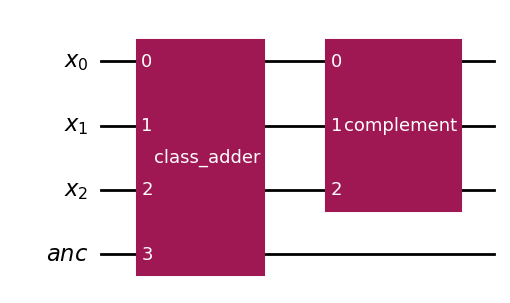

In [15]:
mod_negation(3, 5).draw("mpl")

In [6]:
from qiskit.quantum_info import Statevector
qc = QuantumCircuit(4)
#qc.x(0)
#qc.x(1)
qc.x(2)
qc.append(mod_negation(3, 5), range(4))
psi = Statevector(qc)
psi.draw("latex")

<IPython.core.display.Latex object>